<a href="https://colab.research.google.com/github/thesamokoosi/Zoo/blob/main/adenikezoo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

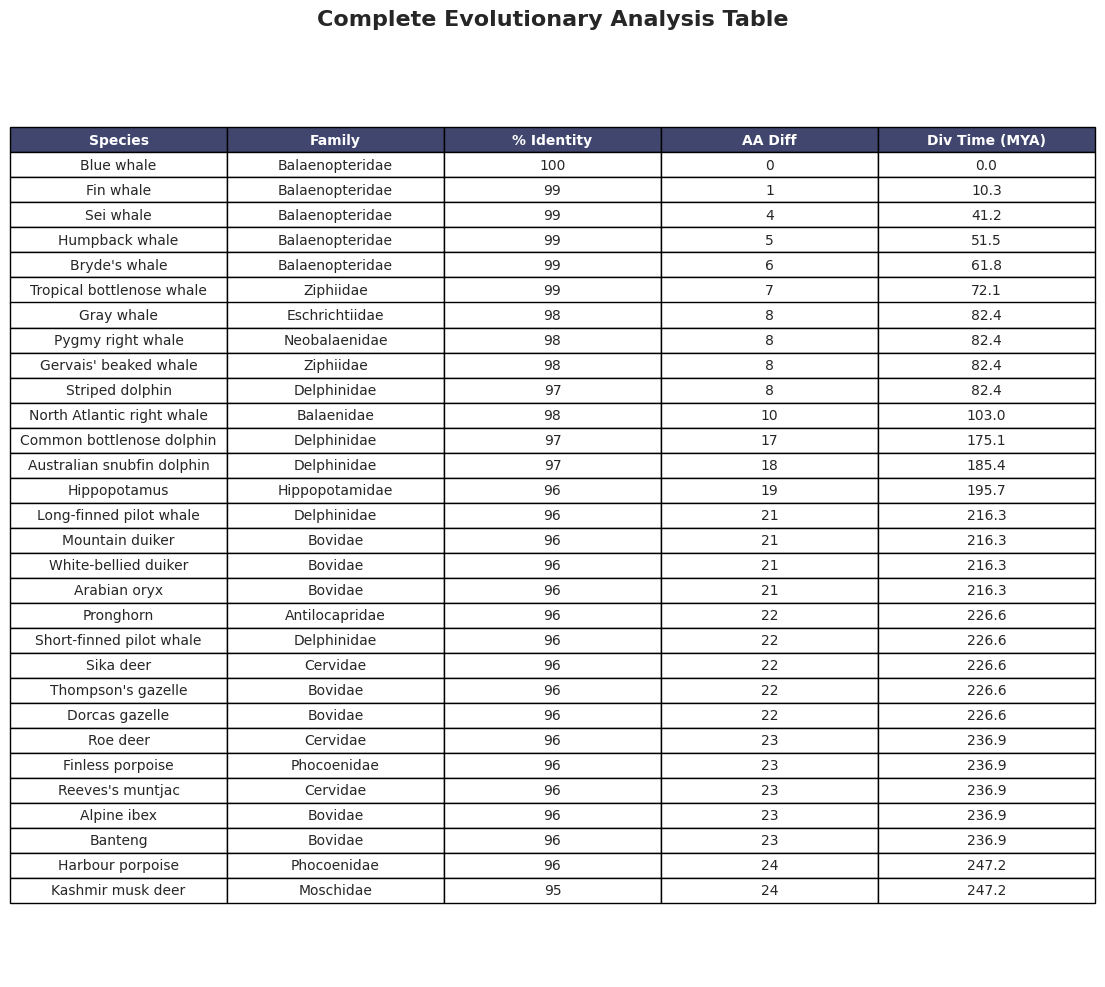

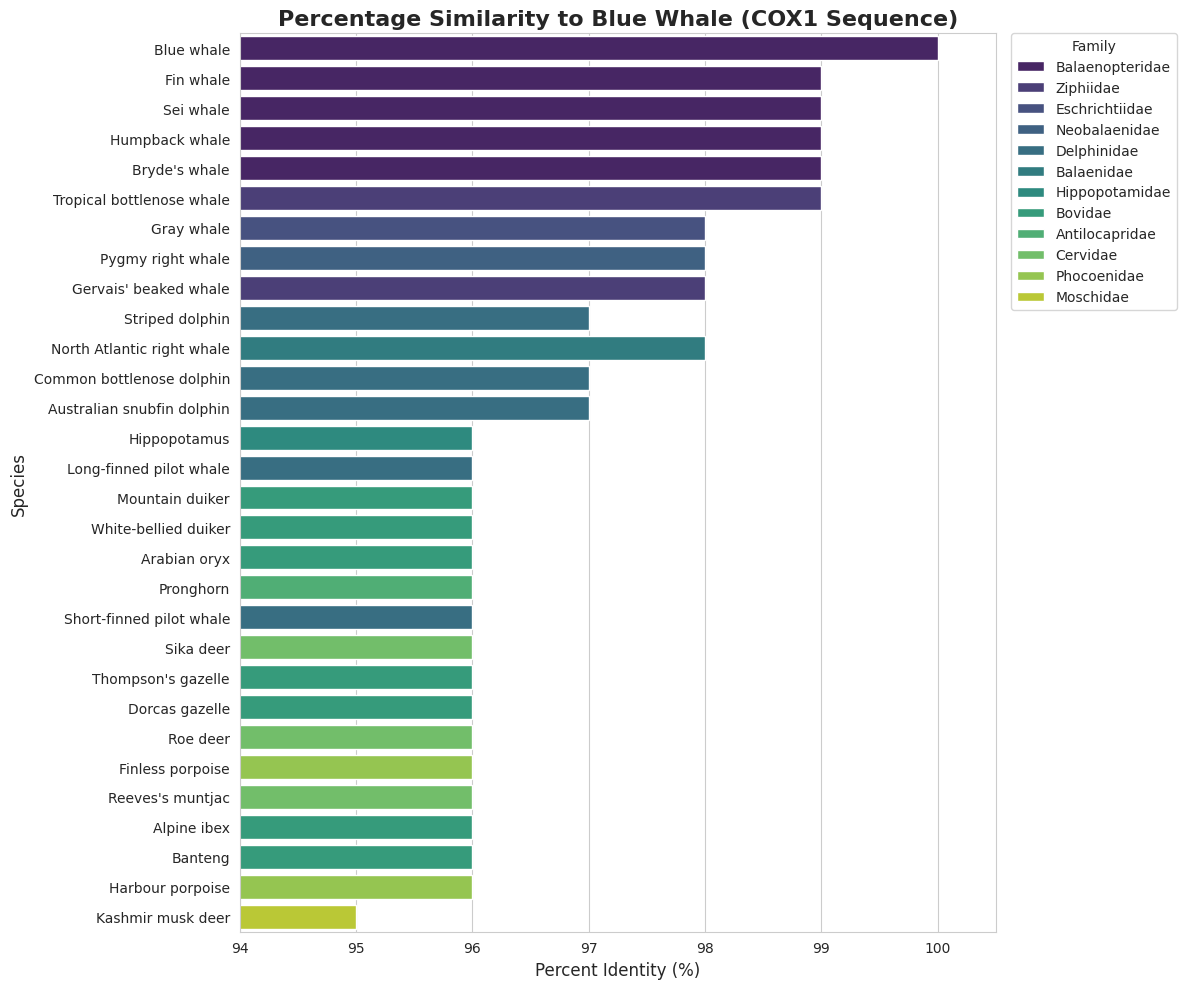

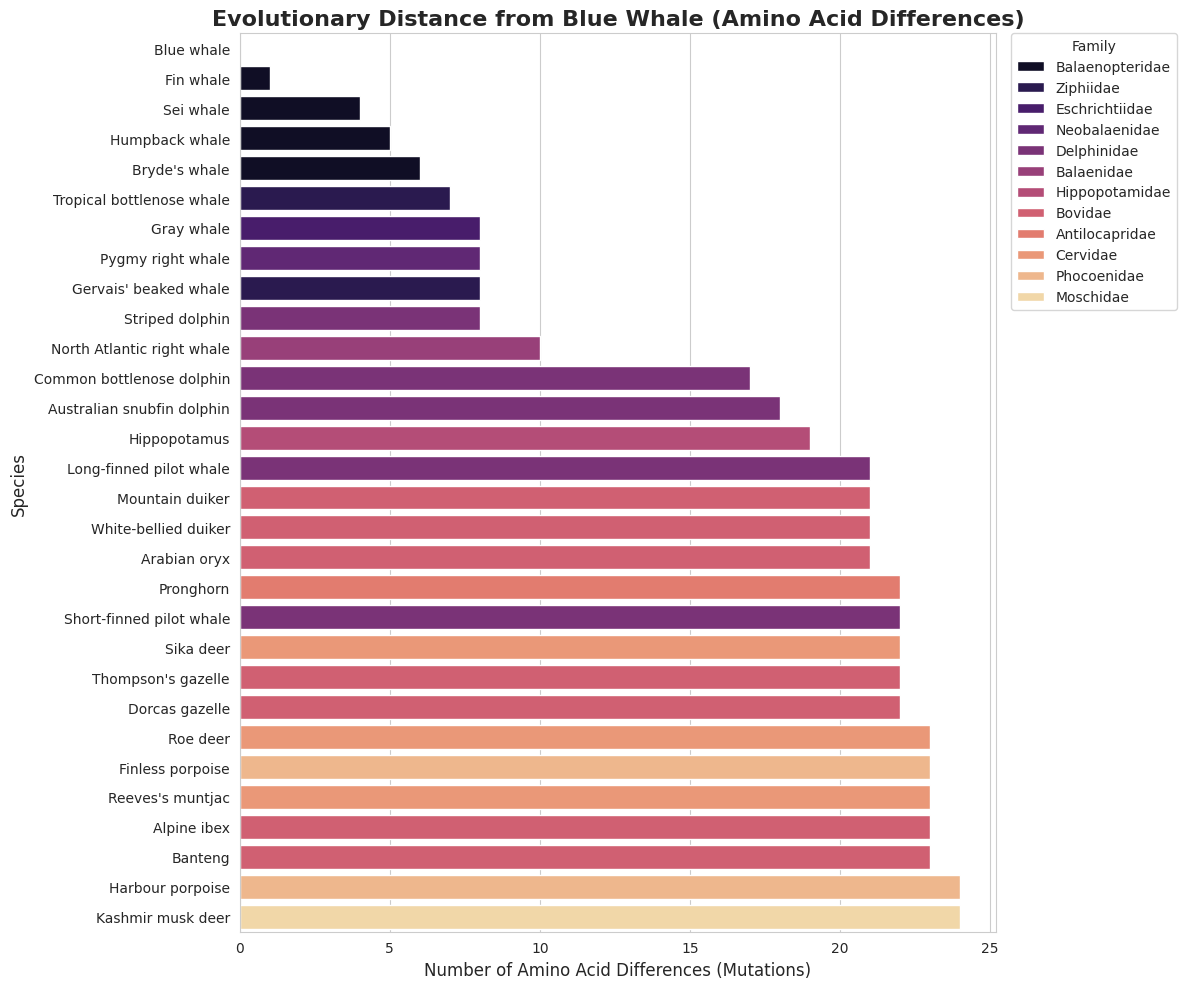

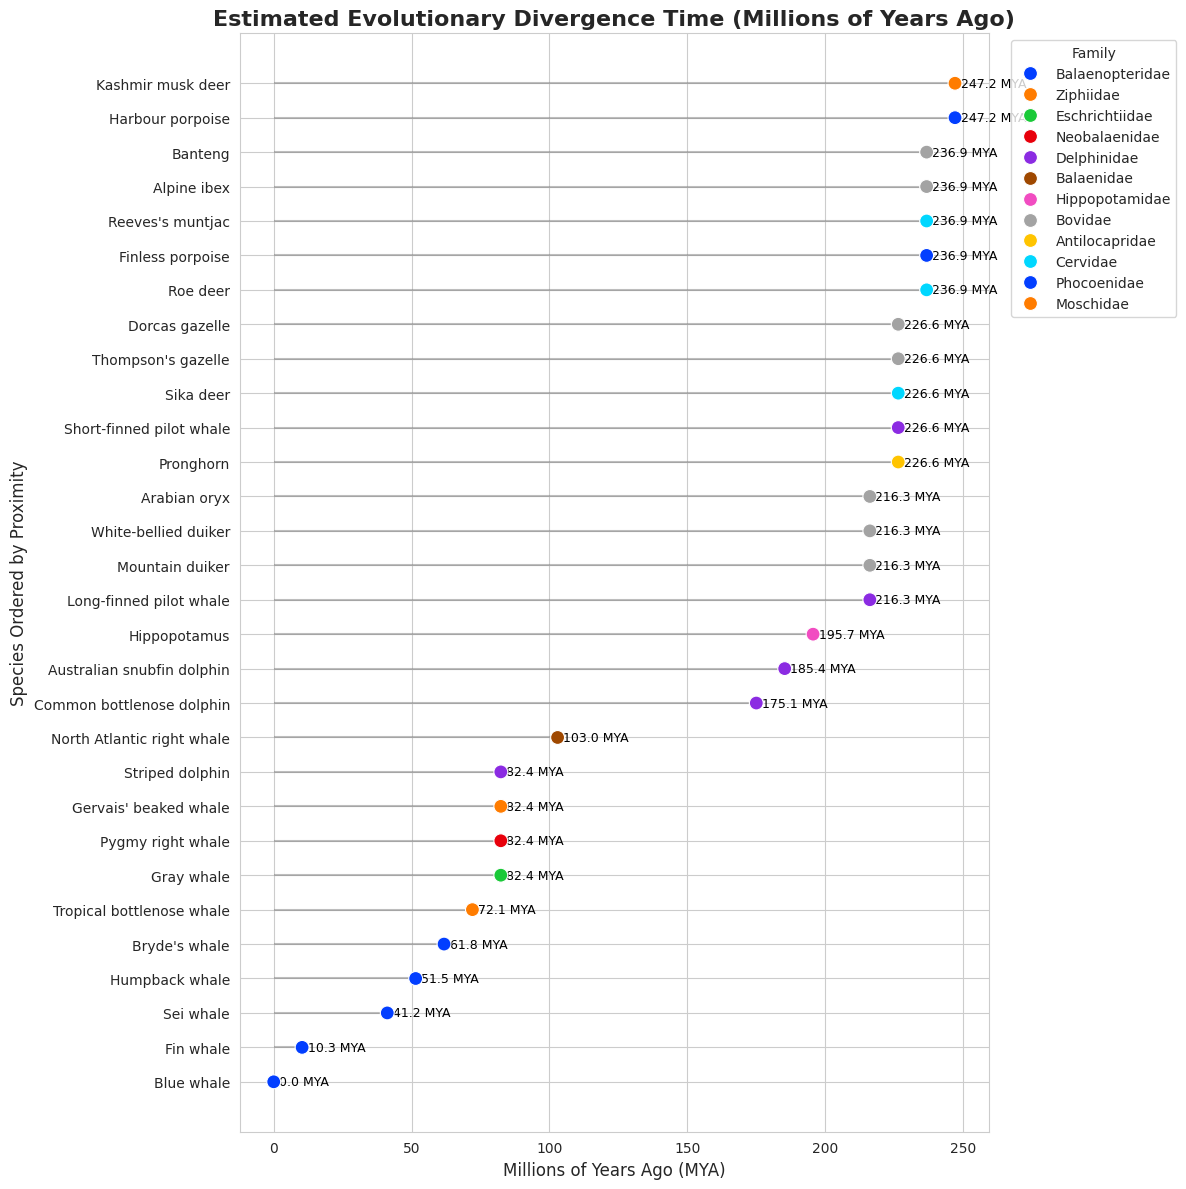

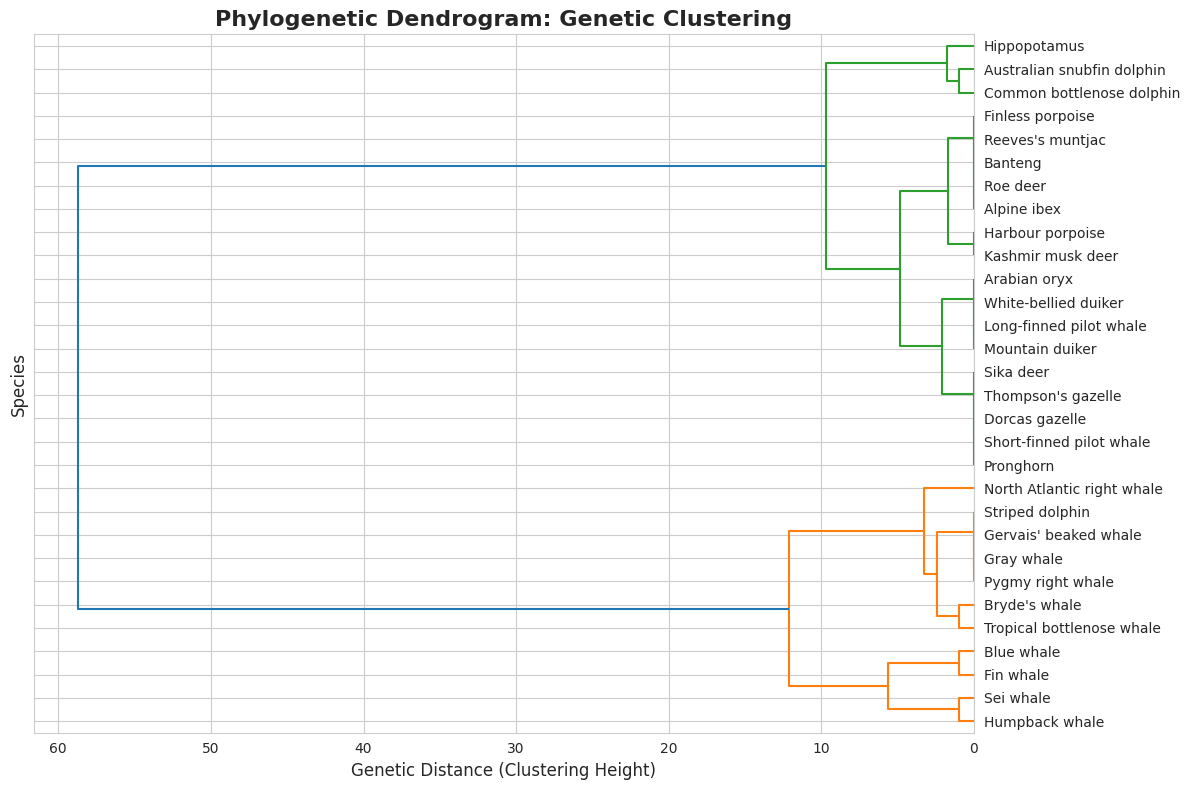

In [ ]:
# ==============================================================================
# STEP 1: IMPORT LIBRARIES & SETUP DATA
# ==============================================================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage

# Create the dataset manually based on Appendix Table 2
data = {
    'Common_Name': [
        "Blue whale", "Fin whale", "Sei whale", "Humpback whale",
        "Bryde's whale", "Gray whale", "Pygmy right whale",
        "Tropical bottlenose whale", "North Atlantic right whale",
        "Gervais' beaked whale", "Australian snubfin dolphin",
        "Common bottlenose dolphin", "Striped dolphin",
        "Long-finned pilot whale", "Hippopotamus", "Mountain duiker",
        "Harbour porpoise", "Short-finned pilot whale",
        "White-bellied duiker", "Pronghorn", "Roe deer", "Alpine ibex",
        "Banteng", "Reeves's muntjac", "Arabian oryx", "Dorcas gazelle",
        "Finless porpoise", "Thompson's gazelle", "Sika deer",
        "Kashmir musk deer"
    ],
    'Family': [
        "Balaenopteridae", "Balaenopteridae", "Balaenopteridae",
        "Balaenopteridae", "Balaenopteridae", "Eschrichtiidae",
        "Neobalaenidae", "Ziphiidae", "Balaenidae", "Ziphiidae",
        "Delphinidae", "Delphinidae", "Delphinidae", "Delphinidae",
        "Hippopotamidae", "Bovidae", "Phocoenidae", "Delphinidae",
        "Bovidae", "Antilocapridae", "Cervidae", "Bovidae", "Bovidae",
        "Cervidae", "Bovidae", "Bovidae", "Phocoenidae", "Bovidae",
        "Cervidae", "Moschidae"
    ],
    'Percent_Identity': [
        100, 99, 99, 99, 99, 98, 98, 99, 98, 98, 97, 97, 97,
        96, 96, 96, 96, 96, 96, 96, 96, 96, 96, 96, 96, 96,
        96, 96, 96, 95
    ],
    # Extracted from the "Actual number..." column
    'Amino_Acid_Diff': [
        0, 1, 4, 5, 6, 8, 8, 7, 10, 8, 18, 17, 8, 21, 19, 21,
        24, 22, 21, 22, 23, 23, 23, 23, 21, 22, 23, 22, 22, 24
    ]
}

df = pd.DataFrame(data)

# ==============================================================================
# STEP 2: CALCULATE DIVERGENCE TIME
# ==============================================================================
# Formula from PDF Section 4.9:
# Mutation Rate = 0.0971 changes per million years
mutation_rate = 0.0971
df['Divergence_Time_MYA'] = round(df['Amino_Acid_Diff'] / mutation_rate, 1)

# Sort the data so the closest relatives are at the top
df_sorted = df.sort_values('Amino_Acid_Diff').reset_index(drop=True)

# Select columns for the table
table_view = df_sorted[['Common_Name', 'Family', 'Percent_Identity', 'Amino_Acid_Diff', 'Divergence_Time_MYA']]

# ==============================================================================
# STEP 3: VISUALIZATION 1 - THE DATA TABLE AS A GRAPHIC
# ==============================================================================
plt.figure(figsize=(14, 12))
ax = plt.gca()
ax.axis('off')

# Create the table
tbl = plt.table(cellText=table_view.values,
                colLabels=["Species", "Family", "% Identity", "AA Diff", "Div Time (MYA)"],
                loc='center',
                cellLoc='center')

tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1, 1.5)

# Bold headers
for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_text_props(weight='bold', color='white')
        cell.set_facecolor('#40466e')

plt.title('Complete Evolutionary Analysis Table', fontsize=16, fontweight='bold', pad=20)
plt.show()

# ==============================================================================
# STEP 4: VISUALIZATION 2 - PERCENTAGE SIMILARITY (WITH LEGEND)
# ==============================================================================
plt.figure(figsize=(12, 10))
sns.set_style("whitegrid")

sns.barplot(x='Percent_Identity', y='Common_Name', data=df_sorted,
            hue='Family', dodge=False, palette='viridis')

plt.xlim(94, 100.5)
plt.title('Percentage Similarity to Blue Whale (COX1 Sequence)', fontsize=16, fontweight='bold')
plt.xlabel('Percent Identity (%)', fontsize=12)
plt.ylabel('Species', fontsize=12)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title="Family", borderaxespad=0)
plt.tight_layout()
plt.show()

# ==============================================================================
# STEP 5: VISUALIZATION 3 - EVOLUTIONARY DISTANCE (AMINO ACID COUNT)
# ==============================================================================
# This is the chart showing the raw count of differences
plt.figure(figsize=(12, 10))
sns.set_style("whitegrid")

sns.barplot(x='Amino_Acid_Diff', y='Common_Name', data=df_sorted,
            hue='Family', dodge=False, palette='magma')

plt.title('Evolutionary Distance from Blue Whale (Amino Acid Differences)', fontsize=16, fontweight='bold')
plt.xlabel('Number of Amino Acid Differences (Mutations)', fontsize=12)
plt.ylabel('Species', fontsize=12)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title="Family", borderaxespad=0)

plt.tight_layout()
plt.show()

# ==============================================================================
# STEP 6: VISUALIZATION 4 - DIVERGENCE TIME (LOLLIPOP CHART)
# ==============================================================================
plt.figure(figsize=(12, 12))

# Draw the lines
plt.hlines(y=df_sorted['Common_Name'], xmin=0, xmax=df_sorted['Divergence_Time_MYA'], color='gray', alpha=0.5)

# Draw the dots
sns.scatterplot(x='Divergence_Time_MYA', y='Common_Name', data=df_sorted, hue='Family', s=100, palette='bright', zorder=5)

# Add Labels
for i in range(df_sorted.shape[0]):
    plt.text(x=df_sorted.Divergence_Time_MYA[i] + 2,
             y=i,
             s=f"{df_sorted.Divergence_Time_MYA[i]} MYA",
             va='center', fontsize=9, color='black')

plt.title('Estimated Evolutionary Divergence Time (Millions of Years Ago)', fontsize=16, fontweight='bold')
plt.xlabel('Millions of Years Ago (MYA)', fontsize=12)
plt.ylabel('Species Ordered by Proximity', fontsize=12)
plt.gca().invert_yaxis()
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title="Family")
plt.tight_layout()
plt.show()

# ==============================================================================
# STEP 7: VISUALIZATION 5 - PHYLOGENETIC TREE (DENDROGRAM)
# ==============================================================================
labels = df['Common_Name'].tolist()
diffs = df['Amino_Acid_Diff'].values.reshape(-1, 1)
linked = linkage(diffs, method='ward')

plt.figure(figsize=(12, 8))
dendrogram(linked,
            orientation='left',
            labels=labels,
            distance_sort='descending',
            show_leaf_counts=True,
            leaf_font_size=10)

plt.title('Phylogenetic Dendrogram: Genetic Clustering', fontsize=16, fontweight='bold')
plt.xlabel('Genetic Distance (Clustering Height)', fontsize=12)
plt.ylabel('Species', fontsize=12)
plt.tight_layout()
plt.show()